## Практика: Работа с модулем requests и osmnx

#### Задача 1. «Поиск объектов инфраструктуры на карте»

Напишите функцию *get_gdf_service(city, services)*, которая:

1. Принимает два аргумента:

    * *city* — строка с названием города и страны (например, 'Гатчина, Россия');

    * *services* — список строк с типами объектов для поиска (например, *['school', 'hospital']*).

2. Использует библиотеку *OSMnx* для поиска указанных объектов в заданном городе.

3. Возвращает объект *GeoDataFrame* (из библиотеки *GeoPandas*) с колонками:

    * *name* — название объекта (если есть);

    * *geometry* — геометрическая информация (точка или полигон);

    * *amenity* — тип объекта (из списка services).

4. Обрабатывает возможные ошибки (например, если город не найден или объекты отсутствуют) и выводит информативное сообщение.

In [ ]:
# решаем задачу вместе, объянить, что такое gdf
import osmnx as ox
import geopandas as gpd

def get_gdf_service(location: str, service_name: list) -> gpd.GeoDataFrame:
    """
    Загружает геоданные объектов заданного типа для указанной локации из OpenStreetMap.

    Parameters
    ----------
    location : str
        Название локации (город, район, адрес и т. д.).
    service_name : List[str]
        Список типов объектов OSM (например, ['restaurant', 'cafe']).

    Returns
    -------
    gpd.GeoDataFrame
        Геоданные объектов с геометрией и атрибутами из OSM.

    Raises
    ------
    Exception
        При ошибках загрузки данных.
    """
    try:
        polygon = ox.geocode_to_gdf(location).iloc[0].geometry
        print(f'Загрузка полигона завершена')
    except Exception as e:
        print(f'Ошибка загрузки {e}')
        polygon = None

    try:
        services = ox.features_from_polygon(polygon=polygon, 
                                    tags= {'amenity' : service_name})
        print(f'Загрузка сервисов завершена. Создан датафрейм {len(services)} на {len(services.columns)}')
    except Exception as e:
        print(f'Ошибка загрузки {e}')
        services = None
    return services

In [ ]:
city = 'Гатчина, Россия'
service = ['school', 'hospital']

schools = get_gdf_service(city, service)

Загрузка полигона завершена
Загрузка сервисов завершена. Создан датафрейм 20 на 26


In [ ]:
schools.head()

geometry amenity  \
element id                                              
node    4124632589  POINT (30.12561 59.56891)  school   
        4191873898   POINT (30.1228 59.57002)  school   
        4972273540   POINT (30.1246 59.57499)  school   
        4972291682   POINT (30.09282 59.5576)  school   
        5808925055  POINT (30.09545 59.55702)  school   

                                                          description  \
element id                                                              
node    4124632589                                             ДЮШС 3   
        4191873898  Гатчинская общеобразовательная школа № 9 с угл...   
        4972273540                                                NaN   
        4972291682                                                NaN   
        5808925055                                                NaN   

                                                     name        name:en  \
element id                                                                 
node    4124632589  Детско-юношеская спортивная школа № 3            NaN   
        4191873898                              Школа № 9            NaN   
        4972273540  Школа имени императора Александра III            NaN   
        4972291682                    НОУ "Школа Экстерн"            NaN   
        5808925055                                Школа 2  School num. 2   

                        opening_hours addr:city addr:country addr:housenumber  \
element id                                                                      
node    4124632589                NaN       NaN          NaN              NaN   
        4191873898                NaN       NaN          NaN              NaN   
        4972273540                NaN       NaN          NaN              NaN   
        4972291682                NaN       NaN          NaN              NaN   
        5808925055  Mo-Sa 08:30-15:00       NaN          NaN              NaN   

                   addr:postcode  ... email healthcare height phone website  \
element id                        ...                                         
node    4124632589           NaN  ...   NaN        NaN    NaN   NaN     NaN   
        4191873898           NaN  ...   NaN        NaN    NaN   NaN     NaN   
        4972273540           NaN  ...   NaN        NaN    NaN   NaN     NaN   
        4972291682           NaN  ...   NaN        NaN    NaN   NaN     NaN   
        5808925055           NaN  ...   NaN        NaN    NaN   NaN     NaN   

                   education fence_type type landuse  ref  
element id                                                 
node    4124632589       NaN        NaN  NaN     NaN  NaN  
        4191873898       NaN        NaN  NaN     NaN  NaN  
        4972273540       NaN        NaN  NaN     NaN  NaN  
        4972291682       NaN        NaN  NaN     NaN  NaN  
        5808925055       NaN        NaN  NaN     NaN  NaN  

[5 rows x 26 columns]

Задача 2. Построение и визуализация дорожной сети города
Условие

Напишите функцию *plot_road_network(city, network_type='drive')*, которая:

1. Принимает два аргумента:

    * *city* — строка с названием города (например, 'Гатчина, Россия');

    * *network_type* — тип дорожной сети (по умолчанию *'drive'*, возможны варианты *'walk', 'bike'*).

2. С помощью библиотеки OSMnx загружает граф дорожной сети для указанного города и типа.

3. Визуализирует граф с помощью встроенной функции *ox.plot_graph()*.

4. Возвращает загруженный граф (в виде объекта).

**Требования к реализации**

* Используйте функцию *ox.graph_from_place()* для загрузки графа.

* В вызове *ox.plot_graph()* укажите параметры для лучшей читаемости: размер фигуры *(figsize=(10, 10))*, цвет дорог *(edge_color='blue')* и цвет фона *(bgcolor='white')*.

* Добавьте обработку исключений: если город не найден, выведите сообщение *"Город '{city}' не найден."* и верните None.

In [ ]:
import osmnx as ox

def plot_road_network(city, network_type='drive'):
    try:
        # Загружаем граф дорожной сети
        G = ox.graph_from_place(city, network_type=network_type)

        # Визуализируем граф
        fig, ax = ox.plot_graph(
            G,
            figsize=(10, 10),
            edge_color='blue',
            bgcolor='white',
            show=False
        )
        ax.set_title(f"Дорожная сеть: {city} ({network_type})")
        return G

    except Exception as e:
        print(f"Город '{city}' не найден. Ошибка {e}")
        return None


Загружено рёбер: 1705
Загружено вершин: 669


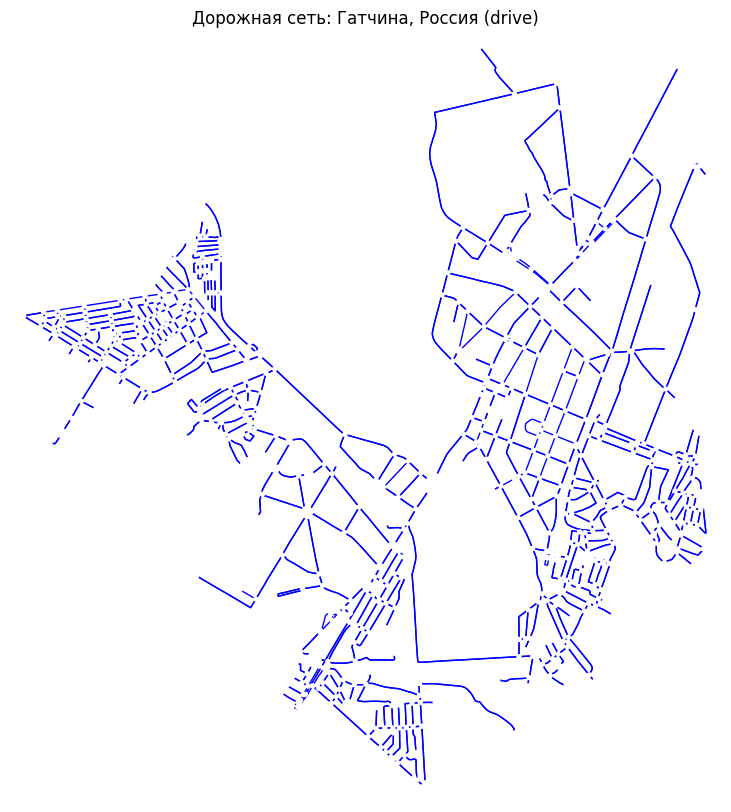

In [ ]:
import osmnx as ox

city = 'Гатчина, Россия'
G = plot_road_network(city, network_type='drive')

if G is not None:
    print(f"Загружено рёбер: {G.number_of_edges()}")
    print(f"Загружено вершин: {G.number_of_nodes()}")


## Задача 3. Получение и анализ границ города
Напишите функцию *get_city_boundaries(city)*, которая:

1. Принимает один аргумент:

    * city — строка с названием города (например, 'Санкт‑Петербург, Россия').

2. Использует OSMnx для получения границ города в виде полигона.

3. Выводит на экран:

    * площадь города в квадратных километрах (вычислите с помощью area / 1_000_000);

    * координаты центроида (центра) города.

4. Визуализирует границы города с помощью *ox.plot_footprints()*.

5. Возвращает объект GeoDataFrame с границами.

**Требования к реализации**

1. Используйте *ox.geocode_to_gdf()* для получения границ.

2. Для расчёта площади используйте атрибут area геометрии (результат в м²).

3. Для центроида — метод centroid объекта геометрии.

4. Обработайте исключения: если город не найден, выведите "Границы города *'{city}'* не найдены." и верните *None*.

In [ ]:
import osmnx as ox
import geopandas as gpd

def get_city_boundaries(city):
    try:
        # Получаем границы города
        gdf = ox.geocode_to_gdf(city)
        if gdf.empty:
            print(f"Границы города '{city}' не найдены.")
            return None

        # Берём первый полигон (обычно единственный)
        polygon = gdf.iloc[0]['geometry']
        area_km2 = round(polygon.area / 1_000_000, 1)  # м² → км²

        # Находим центр
        centroid = polygon.centroid
        lat, lon = centroid.y, centroid.x

        print(f"Площадь {city}: {area_km2} кв. км")
        print(f"Координаты центра: {lat:.4f}, {lon:.4f}")

        # Визуализируем границы
        fig, ax = ox.plot_footprints(
            gdf,
            figsize=(8, 8),
            color='lightblue',
            edgecolor='black',
            show=False
        )
        ax.set_title(f"Границы: {city}")
        return gdf

    except Exception as e:
        print(f"Границы города '{city}' не найдены.")
        return None


In [ ]:
city = 'Санкт-Петербург, Россия'
boundaries = get_city_boundaries(city)

if boundaries is not None:
    print("Границы успешно получены!")


Площадь Санкт-Петербург, Россия: 0.0 кв. км
Координаты центра: 59.9626, 30.0679
Границы города 'Санкт-Петербург, Россия' не найдены.


#### Задача 4. Пишем модуль для получения новостей

**Цель**: разработать инструмент для гибкого получения и обработки новостных данных из внешнего API.

Создайте приложение, котороe:

* Подключается к новостному API [NewsAPI.org](https://newsapi.org/) для получения статей по заданной теме.

* Реализует итератор для последовательного обхода полученных новостей.

* Позволяет пользователю запрашивать конкретные поля из новостей (автор, заголовок, описание, URL и т. д.) в зависимости от его потребностей.

Требования:

1. Оформите решение в виде класса(ов).

2.  Приложение должно принимать как минимум два параметра на входе:

    * ключевое слово/тему для поиска новостей;

    * название поля, которое нужно извлечь из каждой новости (например, 'author', 'title').

3. При запросе к API используйте параметры фильтрации (дата, язык, сортировка и т. п.).

4. Предусмотрите базовую обработку ошибок при обращении к API.

Результат должен выводиться в читаемом формате (например, нумерованный список значений выбранного поля). Если новостей нет — выведите соответствующее сообщение.

In [14]:
import newspaper

news = newspaper.GetNews(
    news_item='city',
    language='ru'
)

In [15]:
# получаем информацию об ответе сервера
news.info()

Дата получения новостей: 2026-03-10.
Срок: за 4 недели.
Было получено новостей: 159


In [17]:
# получаем ceil первых результатов
news.get_features(news_feature='title', ceiling=5)

1. Как криптан в Казахстане без денег остался. Крипто-город и регуляция в 2026
2. [Перевод] Разрыв в неизменяемости: почему Java Records нужны оптики (Lenses)
3. Хотят ли арахниды войны, или SUMMA PRO VERHOEVEN. Часть 2
4. Как писать промпты, создавая смыслы – используем Cloud 4.6 Opus
5. SQL: 5 задач по анализу торгового пространства для ритейла
